# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 12 </span>
## <span style="color:orange"> Keras - Deep & Convolutional Neural Network image recognition </span>

### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

In [5]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

#### Step 1: Load and Process the Data

Keras can conveniently download the MNIST data from the web. All we need to do is import the `mnist` module and use the `load_data()` class, and it will create the training and test data sets or us.

The MNIST set has pre-defined test and training sets, in order to facilitate the comparison of the performance of different models on the data.

Once we have loaded the data, we need to format it in the correct shape.

In [6]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


#### Example: to_categorical

Converts a class vector (integers) to binary class matrix. E.g. for use with categorical_crossentropy.

In [7]:
# Consider an array of 5 labels out of a set of 3 classes {0, 1, 2}:
labels = np.array([0, 2, 1, 2, 0])
# `to_categorical` converts this into a matrix with as many columns as there are classes.
# The number of rows stays the same.
keras.utils.to_categorical(labels)

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

#### Reshape data and convert labels to be used with categorical cross entropy

X_train shape: (60000, 784)
X_test shape: (10000, 784)

an example of a data point with label 4


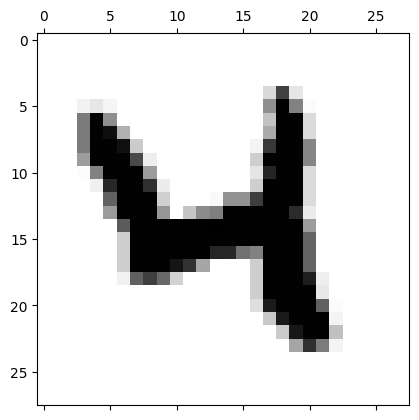

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [8]:
# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

#### Step 2: Define the Neural Net and its Architecture

We can now move on to construct our deep neural net. We shall use Keras's `Sequential()` class to instantiate a model, and will add different deep layers one by one using the `add()` method

For the purposes of our example, it suffices to focus on `Dense` layers for simplicity. Every `Dense()` layer accepts as its first required argument an integer which specifies the number of neurons. The type of activation function for the layer is defined using the `activation` optional argument, the input of which is the name of the activation function in `string` format. Examples include `relu`, `tanh`, `elu`, `sigmoid`, `softmax`. 

In order for our DNN to work properly, we have to make sure that the numbers of input and output neurons for each layer match. Therefore, we specify the shape of the input in the first layer of the model explicitly using the optional argument `input_shape=(N_features,)`. The sequential construction of the model then allows Keras to infer the correct input/output dimensions of all hidden layers automatically. Hence, we only need to specify the size of the softmax output layer to match the number of categories.

In [9]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


#### Step 3: Choose the Optimizer and the Cost Function

Next, we choose the loss function according to which to train the DNN. For classification problems, this is the cross entropy, and since the output data was cast in categorical form, we choose the `categorical_crossentropy` defined in Keras' `losses` module. Depending on the problem of interest one can pick any other suitable loss function. To optimize the weights of the net, we choose SGD. This algorithm is already available to use under Keras' `optimizers` module, but we could use any other built-in one as well. The parameters for the optimizer, such as `lr` (learning rate) or `momentum` are passed using the corresponding optional arguments of the `SGD()` function. All available arguments can be found in Keras' online documentation at [https://keras.io/](https://keras.io/). While the loss function and the optimizer are essential for the training procedure, to test the performance of the model one may want to look at a particular `metric` of performance. For instance, in categorical tasks one typically looks at their `accuracy`, which is defined as the percentage of correctly classified data points. To complete the definition of our model, we use the `compile()` method, with optional arguments for the `optimizer`, `loss`, and the validation `metric` as follows:

In [10]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=SGD(),
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


#### Step 4: Train the model

We train our DNN in minibatches. 

Shuffling the training data during training improves stability of the model. Thus, we train over a number of training epochs. Each epoch corresponds to using **all the train data** divided in minibatches.

Training the DNN is a one-liner using the `fit()` method of the `Sequential` class. The first two required arguments are the training input and output data. As optional arguments, we specify the mini-`batch_size`, the number of training `epochs`, and the test or `validation_data`. To monitor the training procedure for every epoch, we set `verbose=True`. 

## **Submission**

### **Exercise 12.1**

<span style="color:red">Change at will and train your DNN by increasing the number of epochs to an adeuqate value</span>. Try to use at least two other optimizers, different from SGD: <span style="color:red">watch to accuracy and loss for training and validation data and comment on the performances</span>.

To tackle this exercise I decided to use the model already written by the professor and modifying $N_{epochs}$ to a suitable amount in order to have a greater accuracy and also type of `optimizer`. Thus, I decided to write the code using a $\textbf{Grid search}$ over different values of epochs and optimizers. I decided to train the model for a number of epochs $N_{epochs} = 50$. I decided to do this since working with $50$ epochs provides a bettern training for the model, allowing it to reach a great accuracy. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.datasets import mnist

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

img_rows, img_cols = 28, 28 
num_classes = 10 


(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], img_rows * img_cols).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], img_rows * img_cols).astype('float32') / 255

Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
# ========================================================

def create_DNN():
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    model.add(Dense(400, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def compile_model(opt):
    model = create_DNN()
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')


Model compiled successfully and ready to be trained.


In [5]:

import itertools
from tqdm import tqdm

batch_size = 32

epochs_list = [50]
opt_list = ['adam', 'nadam', 'adagrad', 'rmsprop', 'sgd'] 

trained_models = []
trained_histories = []


combination = list(itertools.product(opt_list, epochs_list))

for opt, epochs in tqdm(combination, desc=" ------ GRID SEARCH LOADING..."):
    
    # tqdm.write stampa il messaggio preservando la barra in basso
    tqdm.write(f"\n---> Training: {opt.upper()} ({epochs} epochs) <---")
    
    model_DNN = compile_model(opt)
    
    # Esecuzione del fit (silenzioso per non disturbare la barra principale)
    history = model_DNN.fit(
        X_train, Y_train, 
        batch_size=batch_size, 
        epochs=epochs, 
        #Importante verbose=1 to visualize the progress of a certain model with specific hyperparameters
        verbose=1, 
        #Shuffle the data to sample everytime different batches of collective data
        shuffle=True, 
        validation_data=(X_test, Y_test)
    )
    trained_models.append(model_DNN)
    trained_histories.append(history)
    
    score = model_DNN.evaluate(X_test, Y_test, verbose = 1)
    

    

 ------ GRID SEARCH LOADING...:   0%|          | 0/5 [00:00<?, ?it/s]


---> Training: ADAM (50 epochs) <---
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9190 - loss: 0.2809 - val_acc: 0.9639 - val_loss: 0.1135
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9649 - loss: 0.1226 - val_acc: 0.9735 - val_loss: 0.0912
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9749 - loss: 0.0871 - val_acc: 0.9743 - val_loss: 0.0875
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9801 - loss: 0.0658 - val_acc: 0.9789 - val_loss: 0.0734
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9833 - loss: 0.0523 - val_acc: 0.9765 - val_loss: 0.0957
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9855 - loss: 0.0482 - val_acc: 0.9786 - val_loss: 0.0902
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9881 - loss: 0.0384 - val_acc: 0.9812 - val_loss: 0.0877
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9891 - loss: 0.0352 - val_acc: 0.9791 - val_loss: 0.0964
Ep

 ------ GRID SEARCH LOADING...:  20%|██        | 1/5 [02:36<10:25, 156.41s/it]


---> Training: NADAM (50 epochs) <---
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9194 - loss: 0.2777 - val_acc: 0.9635 - val_loss: 0.1128
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9648 - loss: 0.1221 - val_acc: 0.9720 - val_loss: 0.0897
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9749 - loss: 0.0847 - val_acc: 0.9730 - val_loss: 0.0906
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9810 - loss: 0.0642 - val_acc: 0.9744 - val_loss: 0.0866
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9836 - loss: 0.0549 - val_acc: 0.9788 - val_loss: 0.0859
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9865 - loss: 0.0429 - val_acc: 0.9777 - val_loss: 0.0892
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9882 - loss: 0.0400 - val_acc: 0.9759 - val_loss: 0.1011
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.9897 - loss: 0.0333 - val_acc: 0.9773 - val_loss: 0.1101
E

 ------ GRID SEARCH LOADING...:  40%|████      | 2/5 [05:56<09:05, 181.94s/it]

...

 ------ GRID SEARCH LOADING...:  60%|██████    | 3/5 [08:00<05:10, 155.39s/it]


---> Training: RMSPROP (50 epochs) <---
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ -0s -336us/step - acc: 0.9176 - loss: 0.2817 - val_acc: 0.9663 - val_loss: 0.1173
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9638 - loss: 0.1426 - val_acc: 0.9723 - val_loss: 0.1052
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9690 - loss: 0.1254 - val_acc: 0.9756 - val_loss: 0.1098
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9714 - loss: 0.1225 - val_acc: 0.9732 - val_loss: 0.1539
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9745 - loss: 0.1127 - val_acc: 0.9750 - val_loss: 0.1457
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9748 - loss: 0.1171 - val_acc: 0.9764 - val_loss: 0.1332
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9770 - loss: 0.1104 - val_acc: 0.9765 - val_loss: 0.1800
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9768 - loss: 0.1119 - val_acc: 0.9784 - val_loss: 0.

 ------ GRID SEARCH LOADING...:  80%|████████  | 4/5 [10:20<02:29, 149.33s/it]


---> Training: SGD (50 epochs) <---
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - acc: 0.7782 - loss: 0.7566 - val_acc: 0.9123 - val_loss: 0.3124
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - acc: 0.8915 - loss: 0.3812 - val_acc: 0.9301 - val_loss: 0.2395
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 985us/step - acc: 0.9128 - loss: 0.3081 - val_acc: 0.9407 - val_loss: 0.2003
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - acc: 0.9263 - loss: 0.2616 - val_acc: 0.9485 - val_loss: 0.1738
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - acc: 0.9357 - loss: 0.2321 - val_acc: 0.9541 - val_loss: 0.1554
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 946us/step - acc: 0.9396 - loss: 0.2114 - val_acc: 0.9583 - val_loss: 0.1417
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - acc: 0.9460 - loss: 0.1924 - val_acc: 0.9602 - val_loss: 0.1299
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step - acc: 0.9509 - loss: 0.1741 - val_acc: 0.9636 - val_

 ------ GRID SEARCH LOADING...: 100%|██████████| 5/5 [11:49<00:00, 141.88s/it]


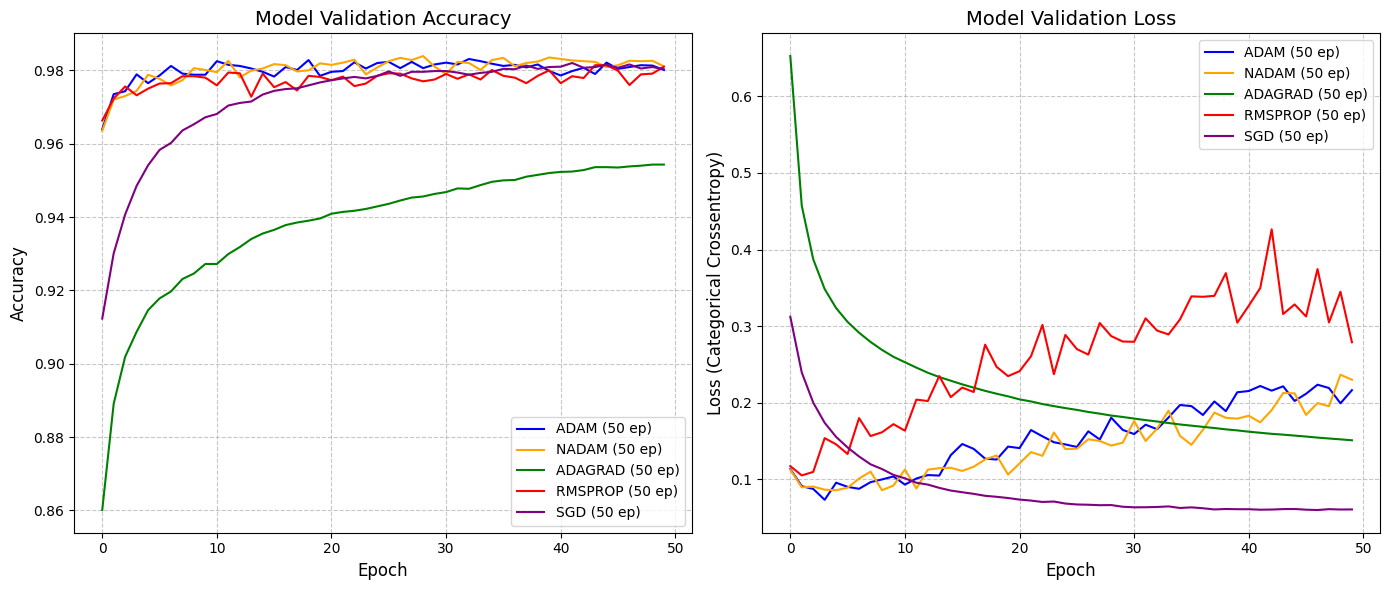

In [6]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Aggiunto un quinto colore ('purple') per coprire tutti e 5 gli ottimizzatori
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, history in enumerate(trained_histories):
    # 2. combination[i] estrae la tupla esatta usata nel training (es. ('adam', 50))
    # Prendiamo l'indice [0] per avere il nome dell'ottimizzatore
    nome_opt = combination[i][0].upper()
    epoche = combination[i][1]
    
    # Creiamo una label descrittiva che include anche le epoche
    label_plot = f"{nome_opt} ({epoche} ep)"
    
    # Grafico 1: Validation Accuracy
    axes[0].plot(history.history['val_acc'], color=colors[i], label=label_plot)
    
    # Grafico 2: Validation Loss
    axes[1].plot(history.history['val_loss'], color=colors[i], label=label_plot)

# Sistemiamo i dettagli del grafico Accuracy
axes[0].set_title('Model Validation Accuracy', fontsize=14)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Sistemiamo i dettagli del grafico Loss
axes[1].set_title('Model Validation Loss', fontsize=14)
axes[1].set_ylabel('Loss (Categorical Crossentropy)', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


From the plots it is possible to compare the performance of the $5$ different optimizers:
- SGD proves to be the most accurate optimizer out of the $5$, without any signs of overfitting the training data
- On the other hand Nadam, RMSPROP, ADAM all reach a great accuracy over few amout of epochs, which is very positive, but after reaching this accuracy they tend to over fit. 
- Adamgrad is the worst optimizer out of the 5 since it reaches a plateau of accuracy $<96\%$, despite it having a steady a descent of the $\textit{crossentropy}$ value over the number of epochs. 

Therefore it is in our interest to verify the performance of the DNN model with the SGD optimizer by using some images and verifying that the model predicts them correctly. An accuracy rate just over $\sim 98\%$ is a great result. 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step


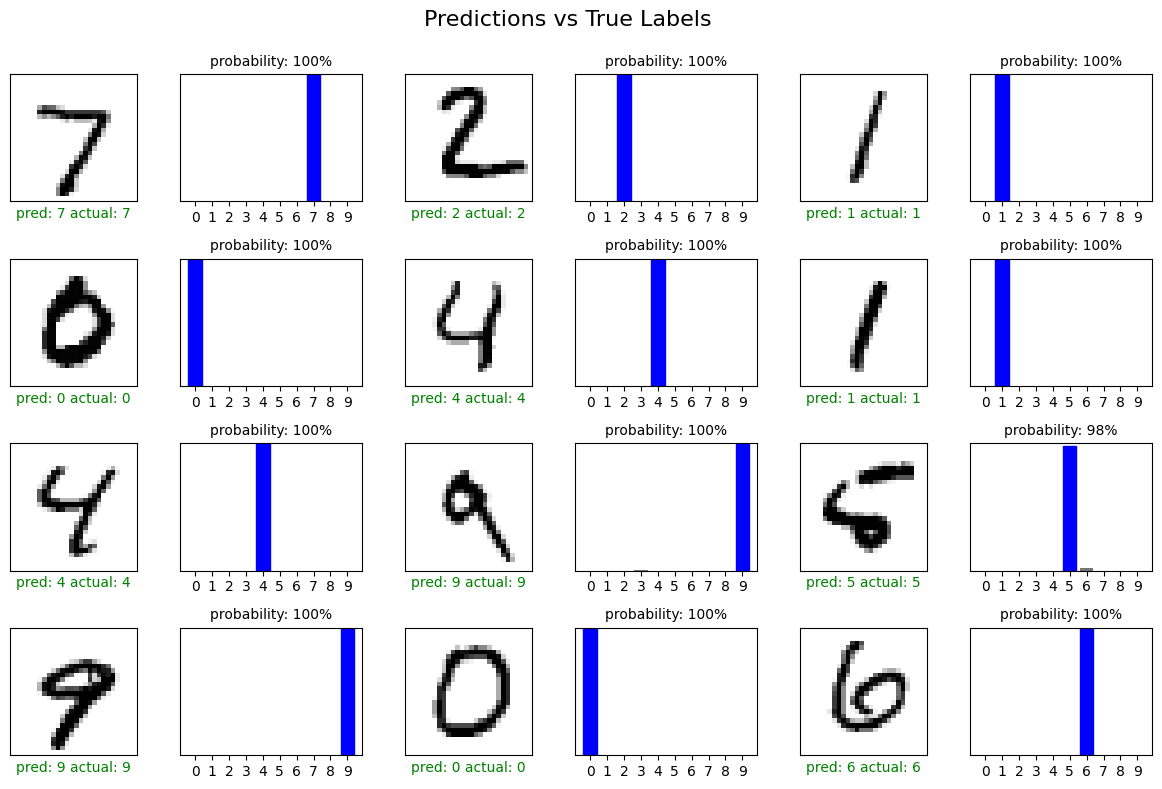

In [7]:
#Copy the already trained model 
model_DNNSGD = trained_models[4]


# Appiattiamo le immagini per il modello Dense
X_test_flat = X_test.reshape(X_test.shape[0], img_rows * img_cols)
predictions = model_DNNSGD.predict(X_test_flat)

# Riportiamo a 2D per il plotting 
X_test_imgs = X_test.reshape(X_test.shape[0], img_rows, img_cols)

# ==========================================
# HELPER 1: Plotta l'immagine e le etichette
# ==========================================
def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], np.argmax(true_labels[i]), images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    # cmap=plt.cm.binary rende i numeri neri su sfondo bianco
    plt.imshow(img, cmap=plt.cm.binary)
    
    predicted_label = np.argmax(predictions_array)
    
    # Assegna il verde se corretto, rosso se errato
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
        
    plt.xlabel("pred: {} actual: {}".format(predicted_label, true_label), color=color)

# ==========================================
# HELPER 2: Plotta l'istogramma delle probabilità
# ==========================================
def plot_value_array(i, predictions_array, true_labels):
    predictions_array, true_label = predictions_array[i], np.argmax(true_labels[i])
    plt.grid(False)
    plt.xticks(range(10)) # Asse X da 0 a 9
    plt.yticks([])
    
    # Crea le barre di base (grigie)
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    
    predicted_label = np.argmax(predictions_array)
    
    # Colora di rosso la barra predetta
    thisplot[predicted_label].set_color('red')
    # Sovrascrive di blu la barra reale (se la rete ha indovinato, diventerà blu)
    thisplot[true_label].set_color('blue')
    
    # Aggiunge la probabilità percentuale sopra l'istogramma
    plt.title(f"probability: {100*np.max(predictions_array):.0f}%", fontsize=10)

# ==========================================
# COSTRUZIONE DELLA GRIGLIA FINALE
# ==========================================
num_rows = 4
num_cols = 3
num_images = num_rows * num_cols

# La larghezza (figsize) è calcolata per ospitare 2 subplots (immagine + grafico) per ogni colonna
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
plt.suptitle("Predictions vs True Labels", fontsize=16)

# Puoi cambiare start_index per visualizzare un blocco diverso di immagini del test set
start_index = 0  

for i in range(num_images):
    idx = start_index + i
    
    # Subplot sinistro: Immagine
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(idx, predictions, Y_test, X_test_imgs)
    
    # Subplot destro: Istogramma probabilità
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(idx, predictions, Y_test)

plt.tight_layout()
plt.subplots_adjust(top=0.90) # Lascia spazio al titolo principale
plt.show()

It is possible to see that the model predicts correctly the value assosciated to the digits for $\textbf{all}$ the images tested, this is a clear syntom of the $98\%$ accuracy rate, even for poorly written numbers. 

### **Exercise 12.2**


Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end. I have merged step 2 and 3 in the following definition of `create_CNN()` that **<span style="color:red">you should complete</span>**:

In [8]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
    
    
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [9]:
#THIS IS INCOMPLETE ... COMPLETE BEFORE EXECUTING IT
num_classes = 10
def create_CNN():
    model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')])

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model



model_CNNnew = create_CNN() # Ho uniformato il nome in maiuscolo per chiarezza

# enumerate genera in automatico l'indice (0, 1, 2...) affiancato all'oggetto
for layer_index, layer in enumerate(model_CNNnew.layers):
    print(layer_index, layer.name)

0 conv2d
1 conv2d_1
2 max_pooling2d
3 dropout_5
4 flatten
5 dense_15
6 dropout_6
7 dense_16


/Users/carlagariboldi/Documents/MARTINO/UNIMI/III anno/Labo_SimulazioneNumerica/es_11/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**What do `Conv2D`, `MaxPooling2D` do differently from `Dense`?**
These are ways of analysing the images by taking in consideration the fact that hand-written images present obvious correlation between the pixels, which means that when looking at a coloured pixel there is a certain probability that the neighbouring pixels will be coloured. `Dense` doesn't take this into account since it looks at the entire image pixel by pixel, but `Conv2D` and `MaxPooling2D` do. 
- `Conv2D` analyses the image using a $d\times d$ kernel to recognize if there are certain patterns in the images. This function clearly is used to exploit in image recognition the correlation between patterns. 
- `Maxpooling2D` saves using typically a $2 \times 2$ kernel the pixel with the greatest intensity. This saves computational work because it reduces the image data by $75\%$ and also prevents overfitting. 

### **Exercise 12.3**

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow):

This plot shows the filters, the kernels of the first layer of the CNN, which in this case are $5\times 5$ images. Now I have to train the CNN that I created over $50$ epochs to then test if it is able to predict (not recognize) what the number the images that I drew represent.

In [13]:
model_CNNnew = create_CNN()

history = model_CNNnew.fit(
        X_train, Y_train, 
        batch_size=batch_size, 
        epochs=epochs, 
        #Importante verbose=1 to visualize the progress of a certain model with specific hyperparameters
        verbose=1, 
        #Shuffle the data to sample everytime different batches of collective data
        shuffle=True, 
        validation_data=(X_test, Y_test)
    )

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.7964 - loss: 0.6418 - val_acc: 0.9376 - val_loss: 0.2103
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9044 - loss: 0.3166 - val_acc: 0.9569 - val_loss: 0.1473
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9280 - loss: 0.2415 - val_acc: 0.9658 - val_loss: 0.1114
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - acc: 0.9450 - loss: 0.1871 - val_acc: 0.9717 - val_loss: 0.0906
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9527 - loss: 0.1585 - val_acc: 0.9771 - val_loss: 0.0696
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9609 - loss: 0.1338 - val_acc: 0.9794 - val_loss: 0.0616
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9643 - loss: 0.1198 - val_acc: 0.9826 - val_loss: 0.0550
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9675 - loss: 0.1075 - val_acc: 0.9839 - val_loss: 0.0504
Epoch 9/50
1875/1875 ━━━

In [ ]:
score = model_CNNnew.evaluate(X_test, Y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.02921086736023426
Test accuracy: 0.9901000261306763


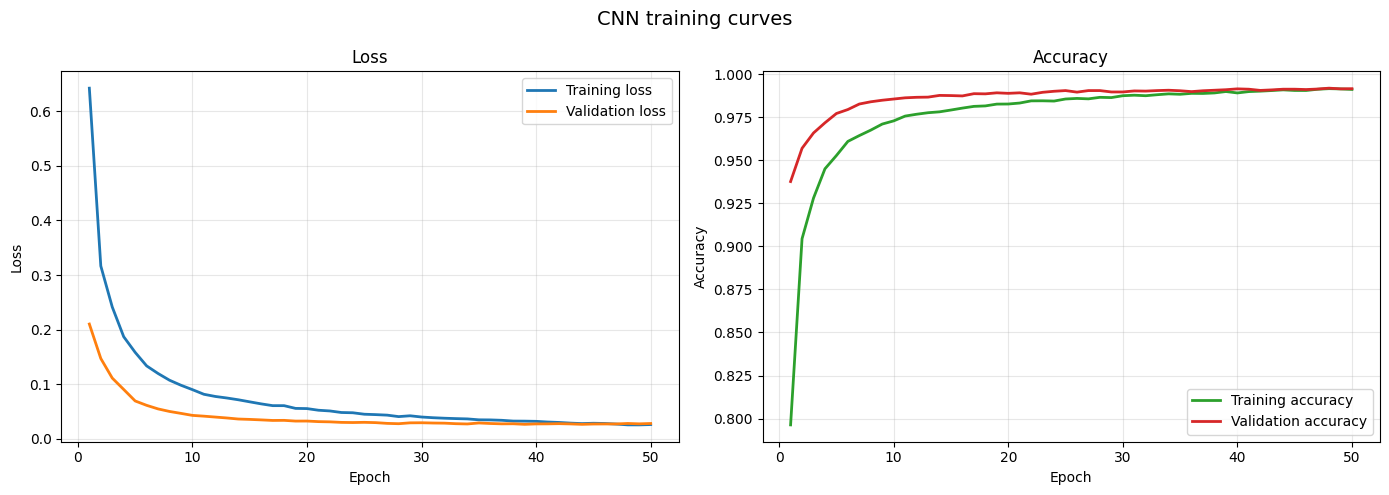

In [14]:
# Plot loss and accuracy over epochs for training and validation sets

# history is already available from the last fit() call
# Use robust key names to support different Keras versions
train_loss = history.history.get("loss")
val_loss = history.history.get("val_loss")
train_acc = history.history.get("acc", history.history.get("accuracy"))
val_acc = history.history.get("val_acc", history.history.get("val_accuracy"))

if train_loss is None or val_loss is None or train_acc is None or val_acc is None:
    raise ValueError("One or more history keys are missing. Check the Keras version and metric names.")

epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN training curves", fontsize=14)

# Loss plot
axes[0].plot(epochs_range, train_loss, label="Training loss", color="tab:blue", linewidth=2)
axes[0].plot(epochs_range, val_loss, label="Validation loss", color="tab:orange", linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, train_acc, label="Training accuracy", color="tab:green", linewidth=2)
axes[1].plot(epochs_range, val_acc, label="Validation accuracy", color="tab:red", linewidth=2)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


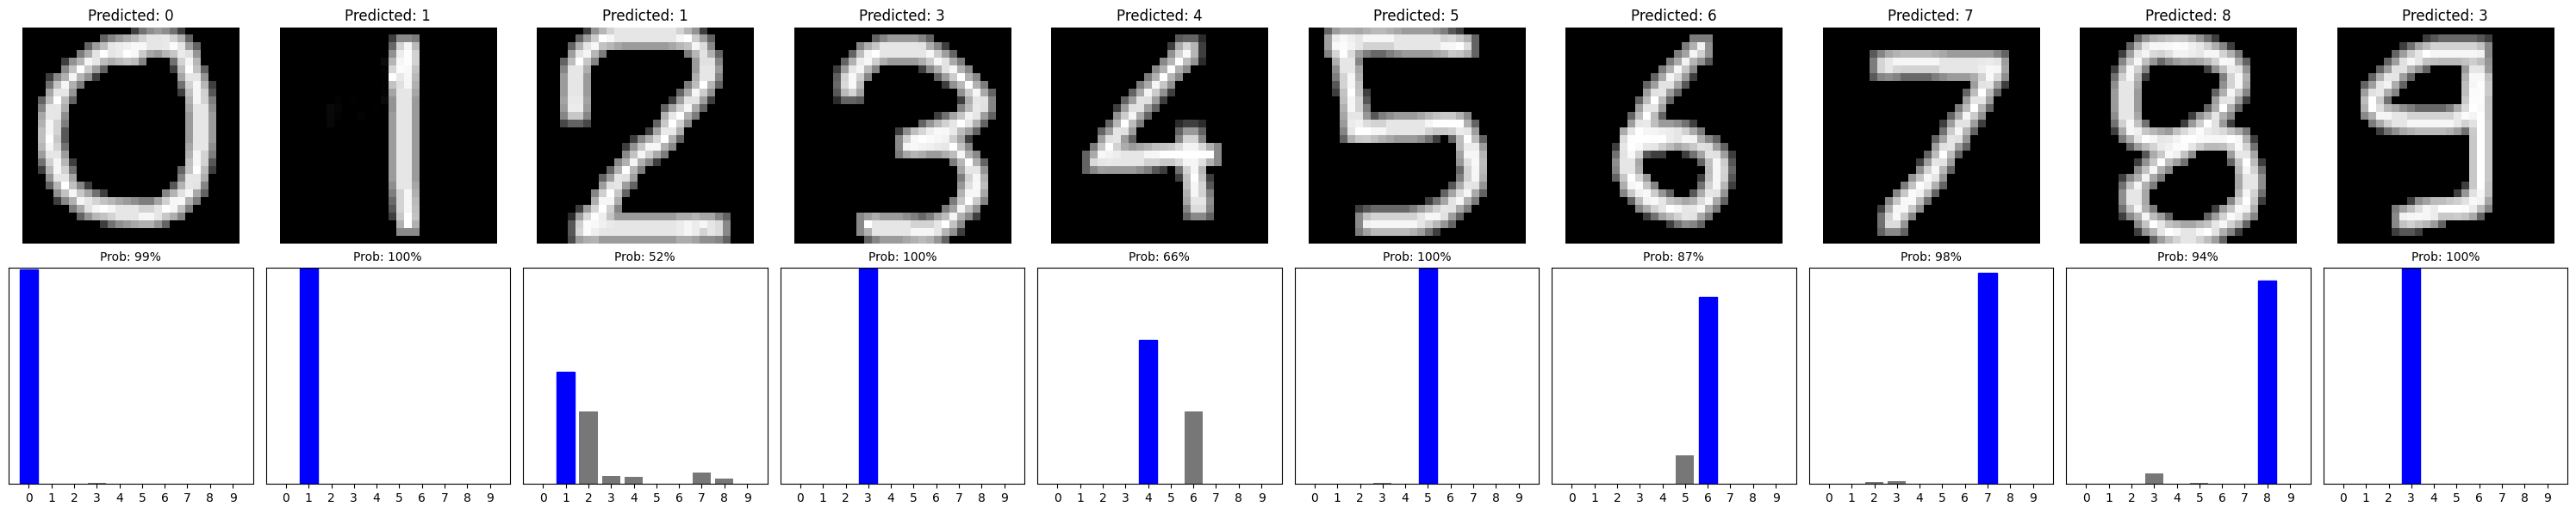

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

files = ['3', '2', '7', '9', '5', '8', '1', '4', '0', '6']
files = sorted(files, key=int)
print(files)
num_files = len(files)

# Figura più alta (6 pollici invece di 4) per ospitare le due righe
plt.figure(figsize=(3 * num_files, 6)) 

for i, file in enumerate(files):
    
    digit_filename = f"IMAGES/{file}.png" 
    digit_in = Image.open(digit_filename).convert('L')
    
    ydim, xdim = digit_in.size
    
    data = np.array(digit_in, dtype=np.float32)
    data = data / 255.0
    
    data_for_cnn = data.reshape(1, xdim, ydim, 1)
    
    # Eseguiamo la predizione
    pred = model_CNNnew.predict(data_for_cnn, verbose=0) 
    
    # pred è una matrice 1x10. Estraiamo il vettore 1D delle probabilità
    predictions_array = pred[0] 
    predicted_digit = np.argmax(predictions_array)
    max_prob = np.max(predictions_array)
    
    # ==========================================
    # SUBPLOT 1 (RIGA SUPERIORE): L'immagine
    # Indice: i + 1 (da 1 a len(files))
    # ==========================================
    ax1 = plt.subplot(2, num_files, i + 1)
    plt.imshow(data.reshape(xdim, ydim), cmap='gray')    
    plt.title(f"Predicted: {predicted_digit}")
    plt.axis('off') 
    
    # ==========================================
    # SUBPLOT 2 (RIGA INFERIORE): Le probabilità
    # Indice: i + 1 + num_files (salta alla seconda riga)
    # ==========================================
    ax2 = plt.subplot(2, num_files, i + 1 + num_files)
    plt.xticks(range(10)) # Assicura che ci siano le etichette da 0 a 9 sull'asse X
    plt.yticks([])        # Nasconde i numeri sull'asse Y per un look più pulito
    plt.ylim([0, 1])      # Blocca l'altezza massima a 1 (100%)
    
    # Crea le 10 barre grigie
    bar_plot = plt.bar(range(10), predictions_array, color="#777777")
    
    # Colora di blu la barra corrispondente alla predizione più alta
    bar_plot[predicted_digit].set_color('blue')
    
    # Mostra la percentuale di sicurezza nel titolo del grafico a barre
    plt.title(f"Prob: {max_prob*100:.0f}%", fontsize=10)

plt.tight_layout()
plt.show()

It is possible to observe that the model particularly strugles in predicting the difference between number $2$ and $7$ and also $5, 3, 9, 8$. It is also evident that the model was trained on figures $1s$ that don't have the left arm on them. The model isn't able to correctly predic numbers $2$ and $9$, I am going to write more samples of handwritten $2$ and $9$ to verify the goodness of the model. However $8/10$ handwritten figures is a good result to begin with. 

['21', '91', '92', '93', '94']


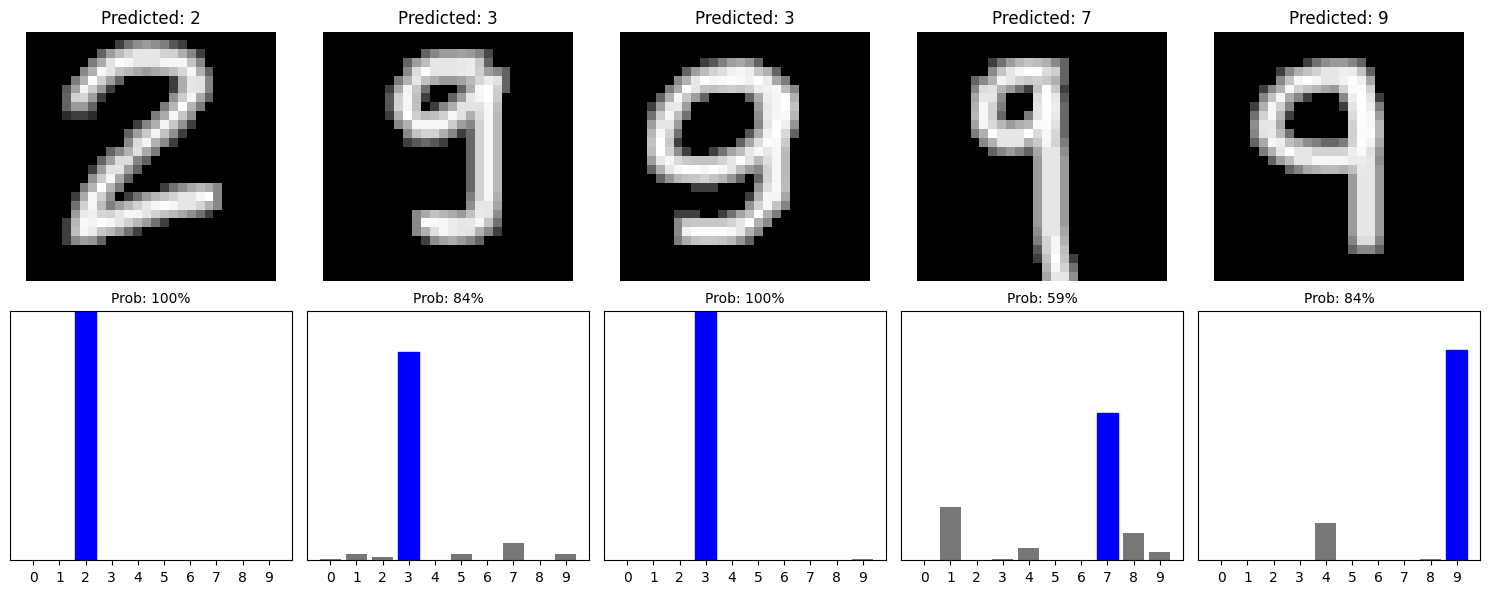

In [17]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

files = ['21', '91', '92', '93', '94' ]
files = sorted(files, key=int)
print(files)
num_files = len(files)

# Figura più alta (6 pollici invece di 4) per ospitare le due righe
plt.figure(figsize=(3 * num_files, 6)) 

for i, file in enumerate(files):
    
    digit_filename = f"IMAGES/{file}.png" 
    digit_in = Image.open(digit_filename).convert('L')
    
    ydim, xdim = digit_in.size
    
    data = np.array(digit_in, dtype=np.float32)
    data = data / 255.0
    
    data_for_cnn = data.reshape(1, xdim, ydim, 1)
    
    # Eseguiamo la predizione
    pred = model_CNNnew.predict(data_for_cnn, verbose=0) 
    
    # pred è una matrice 1x10. Estraiamo il vettore 1D delle probabilità
    predictions_array = pred[0] 
    predicted_digit = np.argmax(predictions_array)
    max_prob = np.max(predictions_array)
    
    # ==========================================
    # SUBPLOT 1 (RIGA SUPERIORE): L'immagine
    # Indice: i + 1 (da 1 a len(files))
    # ==========================================
    ax1 = plt.subplot(2, num_files, i + 1)
    plt.imshow(data.reshape(xdim, ydim), cmap='gray')    
    plt.title(f"Predicted: {predicted_digit}")
    plt.axis('off') 
    
    # ==========================================
    # SUBPLOT 2 (RIGA INFERIORE): Le probabilità
    # Indice: i + 1 + num_files (salta alla seconda riga)
    # ==========================================
    ax2 = plt.subplot(2, num_files, i + 1 + num_files)
    plt.xticks(range(10)) # Assicura che ci siano le etichette da 0 a 9 sull'asse X
    plt.yticks([])        # Nasconde i numeri sull'asse Y per un look più pulito
    plt.ylim([0, 1])      # Blocca l'altezza massima a 1 (100%)
    
    # Crea le 10 barre grigie
    bar_plot = plt.bar(range(10), predictions_array, color="#777777")
    
    # Colora di blu la barra corrispondente alla predizione più alta
    bar_plot[predicted_digit].set_color('blue')
    
    # Mostra la percentuale di sicurezza nel titolo del grafico a barre
    plt.title(f"Prob: {max_prob*100:.0f}%", fontsize=10)

plt.tight_layout()
plt.show()

From these last handwritten drawings it is possible to understand that the majority of the training data was wrote the $9$ without the leg on the bottom since the model strugles to recognize $9s$ written like that. However it is fashinating the fact that the model is able to predict at least $80\%$ of the time new and unseen data. 